# Numpy Exercise 5

### All of the questions in this exercise are attributed to rougier/numpy-100

In [1]:
import numpy as np

#### 61. Find the nearest value from a given value in an array (★★☆)

In [3]:
def find_nearest(arr, value):
    idx = np.abs(arr - value).argmin()
    return arr[idx], idx

arr = np.array([1, 3, 7, 9, 12, 15, 20])
value = 10

nearest, idx = find_nearest(arr, value)
print(f"Array: {arr}")
print(f"Value: {value}")
print(f"Nearest value: {nearest} at index {idx}")

Array: [ 1  3  7  9 12 15 20]
Value: 10
Nearest value: 9 at index 3


#### 62. Considering two arrays with shape (1,3) and (3,1), how to compute their sum using an iterator? (★★☆)

In [7]:
A = np.array([[1, 2, 3]]) 
B = np.array([[4], [5], [6]])

print("A shape:", A.shape)
print("A:")
print(A)
print("\nB shape:", B.shape)
print("B:")
print(B)

# Using broadcasting
result_broadcast = A + B
print("Broadcasting result:")
print(result_broadcast)
print("Shape:", result_broadcast.shape)

A shape: (1, 3)
A:
[[1 2 3]]

B shape: (3, 1)
B:
[[4]
 [5]
 [6]]
Broadcasting result:
[[5 6 7]
 [6 7 8]
 [7 8 9]]
Shape: (3, 3)


#### 63. Create an array class that has a name attribute (★★☆)

In [8]:
class NamedArray(np.ndarray):    
    def __new__(cls, input_array, name="unnamed"):
        obj = np.asarray(input_array).view(cls)
        obj.name = name
        return obj
    
    def __array_finalize__(self, obj):
        if obj is None:
            return
        self.name = getattr(obj, 'name', "unnamed")
    
    def __repr__(self):
        return f"{super().__repr__()}\nName: {self.name}"

# Create named arrays
arr1 = NamedArray([1, 2, 3, 4], "my_array")
print(arr1)

arr2 = NamedArray(np.random.rand(3, 3), "random_matrix")
print("\n", arr2)

# Operations preserve name
arr3 = arr1 + 5
print("\nAfter operation:")
print(arr3)

# Slicing preserves name
arr4 = arr2[0:2, 0:2]
print("\nAfter slicing:")
print(arr4)

[1 2 3 4]

 [[0.40596165 0.88697537 0.24264395]
 [0.0245935  0.0054024  0.76059665]
 [0.67305134 0.08389741 0.4361833 ]]

After operation:
[6 7 8 9]

After slicing:
[[0.40596165 0.88697537]
 [0.0245935  0.0054024 ]]


#### 64. Consider a given vector, how to add 1 to each element indexed by a second vector (be careful with repeated indices)? (★★★)

In [9]:
def add_to_indices(vector, indices):
    result = vector.copy()
    np.add.at(result, indices, 1)
    return result

v = np.array([0, 0, 0, 0, 0])
idx = np.array([0, 1, 2, 1, 0, 3])

print("Original vector:", v)
print("Indices:", idx)
result = add_to_indices(v, idx)
print("After adding 1:", result)

v2 = np.array([0, 0, 0, 0, 0])
v2[idx] += 1 
print("\nWithout handling repeats:", v2)

def add_to_indices_multiple(vector, indices, increments):
    result = vector.copy()
    np.add.at(result, indices, increments)
    return result

v3 = np.array([0, 0, 0, 0, 0])
idx3 = np.array([0, 1, 2, 1, 0, 3])
inc = np.array([1, 2, 3, 4, 5, 6])
result3 = add_to_indices_multiple(v3, idx3, inc)
print(f"\nWith different increments {inc}:")
print("Result:", result3)

Original vector: [0 0 0 0 0]
Indices: [0 1 2 1 0 3]
After adding 1: [2 2 1 1 0]

Without handling repeats: [1 1 1 1 0]

With different increments [1 2 3 4 5 6]:
Result: [6 6 3 6 0]


#### 65. How to accumulate elements of a vector (X) to an array (F) based on an index list (I)? (★★★)

In [10]:
def accumulate_to_F(X, I, F=None):
    """Accumulate X elements into F using indices I."""
    if F is None:
        F = np.zeros(max(I) + 1, dtype=X.dtype)
    
    # Use np.add.at for accumulation with repeated indices
    np.add.at(F, I, X)
    return F

X = np.array([1, 2, 3, 4, 5])
I = np.array([0, 1, 0, 2, 1])  # indices

print("X:", X)
print("I:", I)

F = accumulate_to_F(X, I)
print("F:", F)

# Equivalent to:
print("\nAlternative using loop:")
F2 = np.zeros(3)
for i, x in zip(I, X):
    F2[i] += x
print("F2:", F2)

# With pre-allocated F
F_preallocated = np.array([10, 20, 30])
F3 = accumulate_to_F(X, I, F_preallocated)
print("\nWith pre-allocated F:", F3)

X: [1 2 3 4 5]
I: [0 1 0 2 1]
F: [4 7 4]

Alternative using loop:
F2: [4. 7. 4.]

With pre-allocated F: [14 27 34]


#### 66. Considering a (w,h,3) image of (dtype=ubyte), compute the number of unique colors (★★☆)

In [12]:
def count_unique_colors(image):
    """Count unique colors in an RGB image."""
    # Reshape image to (N, 3) where N = w * h
    h, w, channels = image.shape
    pixels = image.reshape(-1, channels)
    unique_colors = np.unique(pixels, axis=0)
    return len(unique_colors), unique_colors

# Create sample image with unique colors
image = np.random.randint(0, 256, size=(10, 10, 3), dtype=np.uint8)
unique_count, unique_colors = count_unique_colors(image)
print(f"Image shape: {image.shape}")
print(f"Number of unique colors: {unique_count}")
print(f"First 5 unique colors:\n{unique_colors[:5]}")

# With limited colors
image_limited = np.zeros((10, 10, 3), dtype=np.uint8)
image_limited[0, 0] = [255, 0, 0]
image_limited[0, 1] = [0, 255, 0]
image_limited[0, 2] = [0, 0, 255]
image_limited[1, 0] = [255, 0, 0]  # Repeat color
unique_count2, unique_colors2 = count_unique_colors(image_limited)
print(f"\nLimited image unique colors: {unique_count2}")
print("Unique colors:", unique_colors2)

Image shape: (10, 10, 3)
Number of unique colors: 100
First 5 unique colors:
[[  7 221 243]
 [  7 246 213]
 [  8 238 167]
 [ 12 132  44]
 [ 15 227 141]]

Limited image unique colors: 4
Unique colors: [[  0   0   0]
 [  0   0 255]
 [  0 255   0]
 [255   0   0]]


#### 67. Considering a four dimensions array, how to get sum over the last two axis at once? (★★★)

In [13]:
def sum_last_two_axes(arr):
    """Sum over the last two axes of a 4D array."""
    return np.sum(arr, axis=(-2, -1))

# Create 4D array
arr4d = np.random.rand(2, 3, 4, 5)
print("Array shape:", arr4d.shape)

# Sum over last two axes
result = sum_last_two_axes(arr4d)
print("Result shape:", result.shape)  # Should be (2, 3)
print("Result:", result)

Array shape: (2, 3, 4, 5)
Result shape: (2, 3)
Result: [[12.54264258  9.80566011 11.94658632]
 [10.09482193 10.81491631 11.48222873]]


#### 68. Considering a one-dimensional vector D, how to compute means of subsets of D using a vector S of same size describing subset  indices? (★★★)

In [ ]:
def subset_means(D, S):
    unique_indices = np.unique(S)
    means = np.zeros(len(unique_indices))
    
    for i, idx in enumerate(unique_indices):
        means[i] = np.mean(D[S == idx])
    
    return means, unique_indices

# Example
D = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
S = np.array([0, 1, 0, 1, 0, 2, 2, 0, 1, 2])

print("Data D:", D)
print("Subset indices S:", S)

means, indices = subset_means(D, S)
print("Means:", means)
print("Indices:", indices)

Data D: [ 1  2  3  4  5  6  7  8  9 10]
Subset indices S: [0 1 0 1 0 2 2 0 1 2]
Means: [4.25       5.         7.66666667]
Indices: [0 1 2]


#### 69. How to get the diagonal of a dot product? (★★★)

In [19]:
def diagonal_of_dot(A, B):
    full_dot = A @ B
    diag1 = np.diag(full_dot)
    
    return diag1

# Example with square matrices
A = np.random.rand(5, 5)
B = np.random.rand(5, 5)

diag1 = diagonal_of_dot(A, B)
print("A.shape:", A.shape)
print("B.shape:", B.shape)
print("Diagonal from full dot:", diag1)

# Example with non-square matrices
A = np.random.rand(5, 3)
B = np.random.rand(3, 5)
diag1 = diagonal_of_dot(A, B)
print("\nNon-square matrices:")
print("A.shape:", A.shape)
print("B.shape:", B.shape)
print("Diagonal:", diag1)

A.shape: (5, 5)
B.shape: (5, 5)
Diagonal from full dot: [0.93190702 1.00150965 0.56036218 0.81958385 1.57885243]

Non-square matrices:
A.shape: (5, 3)
B.shape: (3, 5)
Diagonal: [1.80564143 0.67872691 0.80030336 0.77588363 0.08302559]


#### 70. Consider the vector [1, 2, 3, 4, 5], how to build a new vector with 3 consecutive zeros interleaved between each value? (★★★)

In [20]:
def interleave_zeros(v, num_zeros=3):
    """Interleave zeros between elements of vector."""
    n = len(v)
    # Create result array with zeros
    result = np.zeros(n + (n - 1) * num_zeros, dtype=v.dtype)
    # Place original elements at positions
    result[::(num_zeros + 1)] = v
    return result

v = np.array([1, 2, 3, 4, 5])
print("Original:", v)
print("With 3 zeros interleaved:", interleave_zeros(v, 3))

Original: [1 2 3 4 5]
With 3 zeros interleaved: [1 0 0 0 2 0 0 0 3 0 0 0 4 0 0 0 5]


#### 71. Consider an array of dimension (5,5,3), how to mulitply it by an array with dimensions (5,5)? (★★★)

In [21]:
def multiply_3d_by_2d(A, B):
    """Multiply 3D array (5,5,3) by 2D array (5,5)."""
    # Method 1: Broadcasting
    return A * B[:, :, np.newaxis]

def multiply_3d_by_2d_einsum(A, B):
    """Using np.einsum."""
    return np.einsum('ijk,ij->ijk', A, B)

# Example
A = np.random.rand(5, 5, 3)
B = np.random.rand(5, 5)

result = multiply_3d_by_2d(A, B)
result_einsum = multiply_3d_by_2d_einsum(A, B)

print("A.shape:", A.shape)
print("B.shape:", B.shape)
print("Result shape:", result.shape)

# Check first slice
print("\nFirst slice of A:")
print(A[:, :, 0].round(3))
print("\nB:")
print(B.round(3))
print("\nResult first slice (broadcasting):")
print(result[:, :, 0].round(3))

print("\nUsing einsum result (first slice):")
print(result_einsum[:, :, 0].round(3))

print("\nMethods match:", np.allclose(result, result_einsum))

A.shape: (5, 5, 3)
B.shape: (5, 5)
Result shape: (5, 5, 3)

First slice of A:
[[0.234 0.24  0.031 0.63  0.289]
 [0.014 0.831 0.437 0.399 0.663]
 [0.045 0.074 0.267 0.576 0.828]
 [0.001 0.538 0.016 0.525 0.586]
 [0.437 0.821 0.388 0.482 0.999]]

B:
[[0.488 0.193 0.175 0.011 0.506]
 [0.264 0.28  0.233 0.871 0.704]
 [0.009 0.697 0.274 0.509 0.938]
 [0.539 0.685 0.386 0.132 0.107]
 [0.25  0.665 0.253 0.927 0.123]]

Result first slice (broadcasting):
[[0.114 0.046 0.005 0.007 0.146]
 [0.004 0.232 0.102 0.348 0.467]
 [0.    0.051 0.073 0.293 0.777]
 [0.    0.368 0.006 0.07  0.063]
 [0.109 0.546 0.098 0.447 0.123]]

Using einsum result (first slice):
[[0.114 0.046 0.005 0.007 0.146]
 [0.004 0.232 0.102 0.348 0.467]
 [0.    0.051 0.073 0.293 0.777]
 [0.    0.368 0.006 0.07  0.063]
 [0.109 0.546 0.098 0.447 0.123]]

Methods match: True


#### 72. How to swap two rows of an array? (★★★)

In [22]:
def swap_rows(arr, i, j):
    """Swap rows i and j in array."""
    arr[i], arr[j] = arr[j], arr[i].copy()
    return arr

def swap_columns(arr, i, j):
    """Swap columns i and j in array."""
    arr[:, i], arr[:, j] = arr[:, j], arr[:, i].copy()
    return arr

# Example with rows
arr = np.arange(12).reshape(4, 3)
print("Original array:")
print(arr)

# Swap rows 0 and 2
swap_rows(arr, 0, 2)
print("\nAfter swapping rows 0 and 2:")
print(arr)

# Using advanced indexing
arr2 = np.arange(12).reshape(4, 3)
arr2[[0, 2]] = arr2[[2, 0]]
print("\nUsing advanced indexing:")
print(arr2)

# Swap columns
arr3 = np.arange(12).reshape(4, 3)
print("\nOriginal for column swap:")
print(arr3)
swap_columns(arr3, 0, 2)
print("After swapping columns 0 and 2:")
print(arr3)

Original array:
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

After swapping rows 0 and 2:
[[ 6  7  8]
 [ 3  4  5]
 [ 0  1  2]
 [ 9 10 11]]

Using advanced indexing:
[[ 6  7  8]
 [ 3  4  5]
 [ 0  1  2]
 [ 9 10 11]]

Original for column swap:
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
After swapping columns 0 and 2:
[[ 2  1  0]
 [ 5  4  3]
 [ 8  7  6]
 [11 10  9]]


#### 73. Consider a set of 10 triplets describing 10 triangles (with shared vertices), find the set of unique line segments composing all the  triangles (★★★)

In [23]:
def unique_segments(triangles):
    edges = []
    for tri in triangles:
        edges.append(tuple(sorted([tri[0], tri[1]])))
        edges.append(tuple(sorted([tri[1], tri[2]])))
        edges.append(tuple(sorted([tri[2], tri[0]])))
    return np.unique(edges, axis=0)

vertices = np.random.randint(0, 20, size=(10, 3))
print("Triangles (vertex indices):")
print(vertices)

segments = unique_segments(vertices)
print(f"\nUnique line segments ({len(segments)}):")
print(segments)

all_vertices = np.unique(vertices)
print(f"\nAll vertices used: {all_vertices}")

def segment_counts(triangles):
    """Count how many triangles use each segment."""
    segments_list = []
    for tri in triangles:
        segments_list.extend([
            tuple(sorted([tri[0], tri[1]])),
            tuple(sorted([tri[1], tri[2]])),
            tuple(sorted([tri[2], tri[0]]))
        ])
    unique, counts = np.unique(segments_list, axis=0, return_counts=True)
    return unique, counts

unique, counts = segment_counts(vertices)
print("\nSegment usage counts:")
for seg, count in zip(unique, counts):
    print(f"{seg}: {count}")

Triangles (vertex indices):
[[12  5  2]
 [ 6  8  5]
 [16  2 14]
 [ 6  2 16]
 [ 6 11  5]
 [ 1 19  2]
 [ 1 15  5]
 [ 3  7  5]
 [11 17 16]
 [ 5  2 11]]

Unique line segments (26):
[[ 1  2]
 [ 1  5]
 [ 1 15]
 [ 1 19]
 [ 2  5]
 [ 2  6]
 [ 2 11]
 [ 2 12]
 [ 2 14]
 [ 2 16]
 [ 2 19]
 [ 3  5]
 [ 3  7]
 [ 5  6]
 [ 5  7]
 [ 5  8]
 [ 5 11]
 [ 5 12]
 [ 5 15]
 [ 6  8]
 [ 6 11]
 [ 6 16]
 [11 16]
 [11 17]
 [14 16]
 [16 17]]

All vertices used: [ 1  2  3  5  6  7  8 11 12 14 15 16 17 19]

Segment usage counts:
[1 2]: 1
[1 5]: 1
[ 1 15]: 1
[ 1 19]: 1
[2 5]: 2
[2 6]: 1
[ 2 11]: 1
[ 2 12]: 1
[ 2 14]: 1
[ 2 16]: 2
[ 2 19]: 1
[3 5]: 1
[3 7]: 1
[5 6]: 2
[5 7]: 1
[5 8]: 1
[ 5 11]: 2
[ 5 12]: 1
[ 5 15]: 1
[6 8]: 1
[ 6 11]: 1
[ 6 16]: 1
[11 16]: 1
[11 17]: 1
[14 16]: 1
[16 17]: 1


#### 74. Given a sorted array C that corresponds to a bincount, how to produce an array A such that np.bincount(A) == C? (★★★)

In [24]:
def inverse_bincount(C):
    """Create array A such that np.bincount(A) == C."""
    A = np.repeat(np.arange(len(C)), C)
    return A

C = np.array([2, 3, 1, 4])  # Counts for values 0, 1, 2, 3
print("Counts C:", C)

A = inverse_bincount(C)
print("Array A:", A)
print("np.bincount(A):", np.bincount(A))
print("Matches:", np.array_equal(np.bincount(A), C))

# With longer array
C2 = np.array([1, 0, 3, 0, 2, 1])
A2 = inverse_bincount(C2)
print(f"\nC: {C2}")
print(f"A: {A2}")
print(f"np.bincount(A): {np.bincount(A2)}")

# Verify for random C
C_random = np.random.randint(0, 5, size=8)
A_random = inverse_bincount(C_random)
print(f"\nRandom C: {C_random}")
print(f"np.bincount(A): {np.bincount(A_random)}")
print("Matches:", np.array_equal(np.bincount(A_random), C_random))

Counts C: [2 3 1 4]
Array A: [0 0 1 1 1 2 3 3 3 3]
np.bincount(A): [2 3 1 4]
Matches: True

C: [1 0 3 0 2 1]
A: [0 2 2 2 4 4 5]
np.bincount(A): [1 0 3 0 2 1]

Random C: [1 3 3 4 3 0 2 1]
np.bincount(A): [1 3 3 4 3 0 2 1]
Matches: True


#### 75. How to compute averages using a sliding window over an array? (★★★)

In [25]:
def sliding_window_avg(arr, window_size):
    """Compute sliding window averages using np.convolve."""
    weights = np.ones(window_size) / window_size
    avg = np.convolve(arr, weights, mode='valid')
    return avg

def sliding_window_avg_strides(arr, window_size):
    """Sliding window average using strides."""
    shape = (arr.size - window_size + 1, window_size)
    strides = (arr.strides[0], arr.strides[0])
    windowed = np.lib.stride_tricks.as_strided(arr, shape=shape, strides=strides)
    return np.mean(windowed, axis=1)

def sliding_window_avg_cumsum(arr, window_size):
    """Sliding window average using cumulative sum."""
    cumsum = np.cumsum(np.concatenate([[0], arr]))
    return (cumsum[window_size:] - cumsum[:-window_size]) / window_size

arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
window_size = 3

avg1 = sliding_window_avg(arr, window_size)
avg2 = sliding_window_avg_strides(arr, window_size)
avg3 = sliding_window_avg_cumsum(arr, window_size)

print("Array:", arr)
print(f"Sliding window average (window size {window_size}):")
print("Method 1 (convolve):", avg1.round(3))
print("Method 2 (strides):", avg2.round(3))
print("Method 3 (cumsum):", avg3.round(3))
print("All methods match:", np.allclose(avg1, avg2) and np.allclose(avg1, avg3))

# With larger window
window_size = 5
avg_large = sliding_window_avg(arr, window_size)
print(f"\nWindow size {window_size}:", avg_large)

Array: [ 1  2  3  4  5  6  7  8  9 10]
Sliding window average (window size 3):
Method 1 (convolve): [2. 3. 4. 5. 6. 7. 8. 9.]
Method 2 (strides): [2. 3. 4. 5. 6. 7. 8. 9.]
Method 3 (cumsum): [2. 3. 4. 5. 6. 7. 8. 9.]
All methods match: True

Window size 5: [3. 4. 5. 6. 7. 8.]


#### 76. Consider a one-dimensional array Z, build a two-dimensional array whose first row is (Z[0],Z[1],Z[2]) and each subsequent row is  shifted by 1 (last row should be (Z[-3],Z[-2],Z[-1]) (★★★)

In [26]:
def shift_2d_from_1d(Z, window_size):
    """Build 2D array where each row is shifted version of 1D array."""
    n = len(Z) - window_size + 1
    result = np.zeros((n, window_size))
    
    for i in range(n):
        result[i] = Z[i:i+window_size]
    
    return result

def shift_2d_from_1d_strides(Z, window_size):
    """Using strides for efficiency."""
    n = len(Z) - window_size + 1
    shape = (n, window_size)
    strides = (Z.strides[0], Z.strides[0])
    return np.lib.stride_tricks.as_strided(Z, shape=shape, strides=strides)

Z = np.arange(1, 15)
window_size = 4

result = shift_2d_from_1d(Z, window_size)
result_strides = shift_2d_from_1d_strides(Z, window_size)

print("Z:", Z)
print(f"\nResult (each row shifted by 1, window_size={window_size}):")
print(result)

print("\nUsing strides:")
print(result_strides)

# Check last row
print(f"\nLast row: {result[-1]}")
print(f"Expected: {Z[-window_size:]}")

# With different window size
window_size = 3
result3 = shift_2d_from_1d(Z, window_size)
print(f"\nWindow size {window_size}:")
print(result3)

Z: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]

Result (each row shifted by 1, window_size=4):
[[ 1.  2.  3.  4.]
 [ 2.  3.  4.  5.]
 [ 3.  4.  5.  6.]
 [ 4.  5.  6.  7.]
 [ 5.  6.  7.  8.]
 [ 6.  7.  8.  9.]
 [ 7.  8.  9. 10.]
 [ 8.  9. 10. 11.]
 [ 9. 10. 11. 12.]
 [10. 11. 12. 13.]
 [11. 12. 13. 14.]]

Using strides:
[[ 1  2  3  4]
 [ 2  3  4  5]
 [ 3  4  5  6]
 [ 4  5  6  7]
 [ 5  6  7  8]
 [ 6  7  8  9]
 [ 7  8  9 10]
 [ 8  9 10 11]
 [ 9 10 11 12]
 [10 11 12 13]
 [11 12 13 14]]

Last row: [11. 12. 13. 14.]
Expected: [11 12 13 14]

Window size 3:
[[ 1.  2.  3.]
 [ 2.  3.  4.]
 [ 3.  4.  5.]
 [ 4.  5.  6.]
 [ 5.  6.  7.]
 [ 6.  7.  8.]
 [ 7.  8.  9.]
 [ 8.  9. 10.]
 [ 9. 10. 11.]
 [10. 11. 12.]
 [11. 12. 13.]
 [12. 13. 14.]]


#### 77. How to negate a boolean, or to change the sign of a float inplace? (★★★)

In [27]:
# Boolean negation in-place
bool_arr = np.array([True, False, True, False, True])
print("Original boolean array:", bool_arr)

# In-place negation using np.logical_not
np.logical_not(bool_arr, out=bool_arr)
print("After in-place negation:", bool_arr)

# For floats, change sign in-place
float_arr = np.array([-1.5, 2.3, -3.7, 4.1, -5.2])
print("\nOriginal float array:", float_arr)

# Method 1: Using np.negative
np.negative(float_arr, out=float_arr)
print("After in-place sign change:", float_arr)

# Method 2: Direct multiplication
float_arr2 = np.array([-1.5, 2.3, -3.7, 4.1, -5.2])
float_arr2 *= -1
print("\nUsing multiplication:", float_arr2)

# For integers
int_arr = np.array([-1, 2, -3, 4, -5])
np.negative(int_arr, out=int_arr)
print("\nInteger array after sign change:", int_arr)

# Conditional sign change (only positive to negative)
arr = np.array([-1, 2, 3, -4, 5])
positive_mask = arr > 0
arr[positive_mask] = -arr[positive_mask]
print("\nOnly positive to negative:", arr)

Original boolean array: [ True False  True False  True]
After in-place negation: [False  True False  True False]

Original float array: [-1.5  2.3 -3.7  4.1 -5.2]
After in-place sign change: [ 1.5 -2.3  3.7 -4.1  5.2]

Using multiplication: [ 1.5 -2.3  3.7 -4.1  5.2]

Integer array after sign change: [ 1 -2  3 -4  5]

Only positive to negative: [-1 -2 -3 -4 -5]


#### 78. Consider 2 sets of points P0,P1 describing lines (2d) and a point p, how to compute distance from p to each line i (P0[i],P1[i])? (★★★)

In [28]:
def distance_point_to_lines(P0, P1, p):
    """
    Compute distance from point p to each line defined by (P0[i], P1[i]).
    Lines are 2D.
    """
    # Vector from P0 to P1
    v = P1 - P0
    # Vector from P0 to p
    w = p - P0
    
    # Projection parameter t = (w·v) / (v·v)
    v_dot_v = np.sum(v * v, axis=1)
    t = np.sum(w * v, axis=1) / v_dot_v
    
    # Clamp t to [0, 1] for line segment (not infinite line)
    t = np.clip(t, 0, 1)
    
    # Closest point on line segment
    closest = P0 + t[:, np.newaxis] * v
    
    # Distance from p to closest point
    distance = np.sqrt(np.sum((p - closest) ** 2, axis=1))
    return distance, closest

# Example
P0 = np.array([[0, 0], [1, 2], [2, 3]])
P1 = np.array([[2, 2], [3, 4], [4, 5]])
p = np.array([3, 1])

print("Line start points (P0):")
print(P0)
print("\nLine end points (P1):")
print(P1)
print(f"\nPoint p: {p}")

distances, closest_points = distance_point_to_lines(P0, P1, p)
print("\nDistances to each line:", distances.round(3))
print("\nClosest points on each line:")
print(closest_points)

# For infinite lines (without clamping)
def distance_point_to_infinite_lines(P0, P1, p):
    v = P1 - P0
    w = p - P0
    v_dot_v = np.sum(v * v, axis=1)
    t = np.sum(w * v, axis=1) / v_dot_v
    closest = P0 + t[:, np.newaxis] * v
    distance = np.sqrt(np.sum((p - closest) ** 2, axis=1))
    return distance, closest

dist_inf, _ = distance_point_to_infinite_lines(P0, P1, p)
print("\nDistances to infinite lines:", dist_inf.round(3))

Line start points (P0):
[[0 0]
 [1 2]
 [2 3]]

Line end points (P1):
[[2 2]
 [3 4]
 [4 5]]

Point p: [3 1]

Distances to each line: [1.414 2.121 2.236]

Closest points on each line:
[[2.  2. ]
 [1.5 2.5]
 [2.  3. ]]

Distances to infinite lines: [1.414 2.121 2.121]


#### 79. Consider 2 sets of points P0,P1 describing lines (2d) and a set of points P, how to compute distance from each point j (P[j]) to each line i (P0[i],P1[i])? (★★★)

In [29]:
def distance_points_to_lines(P0, P1, P):
    """
    Compute distance from each point P[j] to each line defined by (P0[i], P1[i]).
    Returns matrix of shape (len(P), len(P0)).
    """
    n_lines = len(P0)
    n_points = len(P)
    
    # Vector for each line
    v = P1 - P0  # shape (n_lines, 2)
    v_dot_v = np.sum(v * v, axis=1)  # shape (n_lines,)
    
    # For each point, compute distance to each line
    distances = np.zeros((n_points, n_lines))
    
    for j, point in enumerate(P):
        w = point - P0  # shape (n_lines, 2)
        t = np.sum(w * v, axis=1) / v_dot_v  # shape (n_lines,)
        t = np.clip(t, 0, 1)
        closest = P0 + t[:, np.newaxis] * v
        distances[j] = np.sqrt(np.sum((point - closest) ** 2, axis=1))
    
    return distances

# Example
P0 = np.array([[0, 0], [1, 0], [0, 1]])
P1 = np.array([[2, 0], [3, 1], [1, 2]])
P = np.array([[1, 1], [2, 2], [0, 0], [3, 0]])

print("Line start points (P0):")
print(P0)
print("\nLine end points (P1):")
print(P1)
print("\nPoints (P):")
print(P)

distances = distance_points_to_lines(P0, P1, P)
print("\nDistance matrix (points × lines):")
print(distances.round(3))

# For infinite lines
def distance_points_to_infinite_lines(P0, P1, P):
    n_lines = len(P0)
    n_points = len(P)
    
    v = P1 - P0
    v_dot_v = np.sum(v * v, axis=1)
    
    distances = np.zeros((n_points, n_lines))
    
    for j, point in enumerate(P):
        w = point - P0
        t = np.sum(w * v, axis=1) / v_dot_v
        closest = P0 + t[:, np.newaxis] * v
        distances[j] = np.sqrt(np.sum((point - closest) ** 2, axis=1))
    
    return distances

dist_inf = distance_points_to_infinite_lines(P0, P1, P)
print("\nDistance matrix (infinite lines):")
print(dist_inf.round(3))

Line start points (P0):
[[0 0]
 [1 0]
 [0 1]]

Line end points (P1):
[[2 0]
 [3 1]
 [1 2]]

Points (P):
[[1 1]
 [2 2]
 [0 0]
 [3 0]]

Distance matrix (points × lines):
[[1.    0.894 0.707]
 [2.    1.342 1.   ]
 [0.    1.    1.   ]
 [1.    0.894 2.828]]

Distance matrix (infinite lines):
[[1.    0.894 0.707]
 [2.    1.342 0.707]
 [0.    0.447 0.707]
 [0.    0.894 2.828]]


#### 80. Consider an arbitrary array, write a function that extract a subpart with a fixed shape and centered on a given element (pad with a `fill` value when necessary) (★★★)

In [30]:
def extract_centered(arr, center, shape, fill_value=0):
    """
    Extract subpart of arr with given shape centered on center.
    Pad with fill_value when necessary.
    """
    # Get array dimensions
    arr_shape = arr.shape
    
    # Calculate start and end indices
    start = np.array(center) - np.array(shape) // 2
    end = start + np.array(shape)
    
    # Calculate slices for extraction
    slices = []
    paddings = []
    
    for i in range(len(arr_shape)):
        # Adjust for odd shapes
        if shape[i] % 2 == 0:
            start[i] += 1
        
        # Calculate padding needed
        pad_before = max(0, -start[i])
        pad_after = max(0, end[i] - arr_shape[i])
        
        # Clip indices to array bounds
        slice_start = max(0, start[i])
        slice_end = min(arr_shape[i], end[i])
        
        slices.append(slice(slice_start, slice_end))
        paddings.append((pad_before, pad_after))
    
    # Extract subarray
    subarr = arr[tuple(slices)]
    
    # Pad if necessary
    if any(sum(pad) > 0 for pad in paddings):
        subarr = np.pad(subarr, paddings, mode='constant', constant_values=fill_value)
    
    return subarr

# Example with 2D array
arr_2d = np.arange(25).reshape(5, 5)
print("Original array:")
print(arr_2d)

center = (2, 2)
shape = (4, 4)
extracted = extract_centered(arr_2d, center, shape, fill_value=-1)
print(f"\nExtracted {shape} centered at {center} (pad with -1):")
print(extracted)

# Example at edge
center = (0, 4)
shape = (3, 3)
extracted_edge = extract_centered(arr_2d, center, shape, fill_value=-1)
print(f"\nExtracted {shape} centered at {center} (pad with -1):")
print(extracted_edge)

# 3D example
arr_3d = np.arange(27).reshape(3, 3, 3)
center = (1, 1, 1)
shape = (2, 2, 2)
extracted_3d = extract_centered(arr_3d, center, shape, fill_value=-1)
print(f"\n3D array shape: {arr_3d.shape}")
print(f"Extracted {shape} centered at {center}:")
print(extracted_3d)

Original array:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

Extracted (4, 4) centered at (2, 2) (pad with -1):
[[ 6  7  8]
 [11 12 13]
 [16 17 18]]

Extracted (3, 3) centered at (0, 4) (pad with -1):
[[-1 -1 -1]
 [ 3  4 -1]
 [ 8  9 -1]]

3D array shape: (3, 3, 3)
Extracted (2, 2, 2) centered at (1, 1, 1):
[[[13]]]


#### 81. Consider an array Z = [1,2,3,4,5,6,7,8,9,10,11,12,13,14], how to generate an array R = [[1,2,3,4], [2,3,4,5], [3,4,5,6], ..., [11,12,13,14]]? (★★★)

In [31]:
def sliding_windows(Z, window_size):
    """Generate sliding windows from array Z."""
    # Method 1: Using np.lib.stride_tricks.sliding_window_view (NumPy 1.20+)
    try:
        from numpy.lib.stride_tricks import sliding_window_view
        return sliding_window_view(Z, window_shape=window_size)
    except ImportError:
        pass
    
    # Method 2: Manual implementation
    n = len(Z) - window_size + 1
    result = np.zeros((n, window_size), dtype=Z.dtype)
    for i in range(n):
        result[i] = Z[i:i+window_size]
    return result

Z = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
window_size = 4

R = sliding_windows(Z, window_size)
print("Z:", Z)
print(f"\nSliding windows (size {window_size}):")
print(R)

# Alternative using broadcasting
def sliding_windows_broadcast(Z, window_size):
    n = len(Z) - window_size + 1
    indices = np.arange(window_size)[np.newaxis, :] + np.arange(n)[:, np.newaxis]
    return Z[indices]

R_broadcast = sliding_windows_broadcast(Z, window_size)
print("\nUsing broadcasting:")
print(R_broadcast)

# Different window sizes
print("\nWindow size 3:")
print(sliding_windows(Z, 3))

Z: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]

Sliding windows (size 4):
[[ 1  2  3  4]
 [ 2  3  4  5]
 [ 3  4  5  6]
 [ 4  5  6  7]
 [ 5  6  7  8]
 [ 6  7  8  9]
 [ 7  8  9 10]
 [ 8  9 10 11]
 [ 9 10 11 12]
 [10 11 12 13]
 [11 12 13 14]]

Using broadcasting:
[[ 1  2  3  4]
 [ 2  3  4  5]
 [ 3  4  5  6]
 [ 4  5  6  7]
 [ 5  6  7  8]
 [ 6  7  8  9]
 [ 7  8  9 10]
 [ 8  9 10 11]
 [ 9 10 11 12]
 [10 11 12 13]
 [11 12 13 14]]

Window size 3:
[[ 1  2  3]
 [ 2  3  4]
 [ 3  4  5]
 [ 4  5  6]
 [ 5  6  7]
 [ 6  7  8]
 [ 7  8  9]
 [ 8  9 10]
 [ 9 10 11]
 [10 11 12]
 [11 12 13]
 [12 13 14]]


#### 82. Compute a matrix rank (★★★)

In [ ]:
def matrix_rank(A, tol=None):
    u, s, vh = np.linalg.svd(A, full_matrices=False)
    
    if tol is None:
        tol = s.max() * max(A.shape) * np.finfo(s.dtype).eps
    
    rank = np.sum(s > tol)
    return rank, s

# Examples
A1 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])  # rank 2
rank1, s1 = matrix_rank(A1)
print("Matrix A1:")
print(A1)
print(f"Rank: {rank1}")
print(f"Singular values: {s1.round(4)}")

A2 = np.eye(5)  # rank 5
rank2, s2 = matrix_rank(A2)
print("\nMatrix A2 (identity 5x5):")
print(f"Rank: {rank2}")
print(f"Singular values: {s2.round(4)}")

A3 = np.array([[1, 0, 0], [0, 0, 0], [0, 0, 0]])  # rank 1
rank3, s3 = matrix_rank(A3)
print("\nMatrix A3:")
print(A3)
print(f"Rank: {rank3}")

# Using numpy's built-in rank
print(f"\nNumPy's built-in rank (A1): {np.linalg.matrix_rank(A1)}")
print(f"NumPy's built-in rank (A2): {np.linalg.matrix_rank(A2)}")

Matrix A1:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Rank: 2
Singular values: [16.8481  1.0684  0.    ]

Matrix A2 (identity 5x5):
Rank: 5
Singular values: [1. 1. 1. 1. 1.]

Matrix A3:
[[1 0 0]
 [0 0 0]
 [0 0 0]]
Rank: 1

NumPy's built-in rank (A1): 2
NumPy's built-in rank (A2): 5


#### 83. How to find the most frequent value in an array?

In [35]:
def most_frequent(arr):
    values, counts = np.unique(arr, return_counts=True)
    max_count_idx = np.argmax(counts)
    return values[max_count_idx], counts[max_count_idx]

def most_frequent2(arr):
    """Alternative using np.bincount (for non-negative integers)."""
    if arr.dtype.kind in 'iu':
        counts = np.bincount(arr)
        max_count_idx = np.argmax(counts)
        return max_count_idx, counts[max_count_idx]
    else:
        return None

# Example with integers
arr_int = np.array([1, 2, 3, 1, 2, 1, 3, 3, 3, 4, 1, 1])
print("Array:", arr_int)
value, count = most_frequent(arr_int)
print(f"Most frequent value: {value} (appears {count} times)")

# Example with strings
arr_str = np.array(['a', 'b', 'c', 'a', 'b', 'a', 'd', 'a'])
print("\nArray:", arr_str)
value, count = most_frequent(arr_str)
print(f"Most frequent value: {value} (appears {count} times)")

# Example with floats
arr_float = np.array([1.1, 2.2, 1.1, 3.3, 1.1, 2.2, 1.1])
print("\nArray:", arr_float)
value, count = most_frequent(arr_float)
print(f"Most frequent value: {value} (appears {count} times)")

Array: [1 2 3 1 2 1 3 3 3 4 1 1]
Most frequent value: 1 (appears 5 times)

Array: ['a' 'b' 'c' 'a' 'b' 'a' 'd' 'a']
Most frequent value: a (appears 4 times)

Array: [1.1 2.2 1.1 3.3 1.1 2.2 1.1]
Most frequent value: 1.1 (appears 4 times)


#### 84. Extract all the contiguous 3x3 blocks from a random 10x10 matrix (★★★)

In [36]:
def extract_blocks(arr, block_size):
    """Extract all contiguous blocks from array."""
    # Method 1: Using stride_tricks
    h, w = arr.shape
    block_h, block_w = block_size
    
    shape = (h - block_h + 1, w - block_w + 1, block_h, block_w)
    strides = (arr.strides[0], arr.strides[1], arr.strides[0], arr.strides[1])
    
    blocks = np.lib.stride_tricks.as_strided(arr, shape=shape, strides=strides)
    return blocks

# Create 10x10 random matrix
matrix = np.random.randint(0, 10, size=(10, 10))
print("Original 10x10 matrix:")
print(matrix)

blocks = extract_blocks(matrix, (3, 3))
print(f"\nShape of blocks: {blocks.shape}")  # (8, 8, 3, 3)
print(f"Number of 3x3 blocks: {blocks.shape[0] * blocks.shape[1]}")

# Show first block
print("\nFirst block (top-left):")
print(blocks[0, 0])

# Show a specific block
print("\nBlock at position (2, 3):")
print(blocks[2, 3])

# Extract block sums
block_sums = blocks.sum(axis=(-2, -1))
print("\nSum of each block:")
print(block_sums)

Original 10x10 matrix:
[[2 7 6 5 7 2 2 1 2 4]
 [4 7 1 3 5 9 5 8 6 0]
 [4 4 7 1 1 0 0 4 1 5]
 [8 0 8 8 4 1 4 3 4 5]
 [7 5 2 1 9 1 0 4 0 2]
 [5 1 1 4 1 0 2 2 4 5]
 [2 5 2 9 0 0 9 5 8 1]
 [1 5 6 3 8 1 4 5 7 5]
 [8 3 6 5 2 4 5 7 8 1]
 [4 0 9 2 9 3 6 2 3 2]]

Shape of blocks: (8, 8, 3, 3)
Number of 3x3 blocks: 64

First block (top-left):
[[2 7 6]
 [4 7 1]
 [4 4 7]]

Block at position (2, 3):
[[1 1 0]
 [8 4 1]
 [1 9 1]]

Sum of each block:
[[42 41 36 33 31 31 29 31]
 [43 39 38 32 29 34 35 36]
 [45 36 41 26 20 17 20 28]
 [37 30 38 29 22 17 23 29]
 [30 30 29 25 22 23 34 31]
 [28 36 34 26 25 28 46 42]
 [38 44 41 32 33 40 58 47]
 [42 39 50 37 42 37 47 40]]


#### 85. Create a 2D array subclass such that Z[i,j] == Z[j,i] (★★★)

In [38]:
class SymmetricArray(np.ndarray):    
    def __new__(cls, input_array):
        obj = np.asarray(input_array).view(cls)
        obj = (obj + obj.T) / 2
        return obj
    
    def __setitem__(self, key, value):
        if isinstance(key, tuple) and len(key) == 2:
            super().__setitem__(key, value)
            super().__setitem__((key[1], key[0]), value)
        else:
            super().__setitem__(key, value)
    
    def __array_finalize__(self, obj):
        if obj is None:
            return

data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
sym_arr = SymmetricArray(data)
print("Original data:")
print(data)
print("\nSymmetric array:")
print(sym_arr)

print("\nChecking symmetry:")
print("Is symmetric?", np.allclose(sym_arr, sym_arr.T))

sym_arr[0, 1] = 10
print("\nAfter setting [0,1] = 10:")
print(sym_arr)

random_data = np.random.rand(4, 4)
sym_random = SymmetricArray(random_data)
print("\nRandom symmetric array:")
print(sym_random.round(3))
print("Is symmetric?", np.allclose(sym_random, sym_random.T))

Original data:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Symmetric array:
[[1. 3. 5.]
 [3. 5. 7.]
 [5. 7. 9.]]

Checking symmetry:
Is symmetric? True

After setting [0,1] = 10:
[[ 1. 10.  5.]
 [10.  5.  7.]
 [ 5.  7.  9.]]

Random symmetric array:
[[0.734 0.432 0.636 0.566]
 [0.432 0.789 0.563 0.775]
 [0.636 0.563 0.91  0.777]
 [0.566 0.775 0.777 0.199]]
Is symmetric? True


#### 86. Consider a set of p matrices wich shape (n,n) and a set of p vectors with shape (n,1). How to compute the sum of of the p matrix products at once? (result has shape (n,1)) (★★★)

In [ ]:
def sum_matrix_vector_products(matrices, vectors):
    """Compute sum of matrix-vector products for p matrices and vectors."""
    # matrices: shape (p, n, n)
    # vectors: shape (p, n, 1)
    
    # Method 1: Using np.einsum
    result1 = np.einsum('pij,pj->pi', matrices, vectors.squeeze()).sum(axis=0, keepdims=True).T
    
    # Method 2: Using broadcasting and matmul
    result2 = np.matmul(matrices, vectors).sum(axis=0)
    
    return result1, result2

# Example
p = 5
n = 3

matrices = np.random.rand(p, n, n)
vectors = np.random.rand(p, n, 1)

print(f"Matrices shape: {matrices.shape}")
print(f"Vectors shape: {vectors.shape}")

result1, result2 = sum_matrix_vector_products(matrices, vectors)

print(f"\nResult shape: {result1.shape}")
print("\nResult:")
print(result1.squeeze())

print("\nMethods match:", np.allclose(result1, result2))

def sum_matrix_vector_products_alt(matrices, vectors):
    return np.sum(matrices @ vectors, axis=0)

result3 = sum_matrix_vector_products_alt(matrices, vectors)
print("\nAlternative method shape:", result3.shape)
print("Matches previous:", np.allclose(result1, result3))

Matrices shape: (5, 3, 3)
Vectors shape: (5, 3, 1)

Result shape: (3, 1)

Result:
[2.66464538 4.46800922 4.81393846]

Methods match: True

Alternative method shape: (3, 1)
Matches previous: True


#### 87. Consider a 16x16 array, how to get the block-sum (block size is 4x4)? (★★★)

In [40]:
def block_sum(arr, block_size):
    h, w = arr.shape
    block_h, block_w = block_size
    
    reshaped = arr.reshape(h // block_h, block_h, w // block_w, block_w)
    block_sums = reshaped.sum(axis=(1, 3))
    
    return block_sums

arr = np.random.randint(0, 10, size=(16, 16))
print("Array shape:", arr.shape)

block_sums = block_sum(arr, (4, 4))
print(f"Block sums shape: {block_sums.shape}")
print("\nBlock sums:")
print(block_sums)

manual = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        manual[i, j] = arr[i*4:(i+1)*4, j*4:(j+1)*4].sum()

print("\nManual block sums:")
print(manual)
print("Matches:", np.allclose(block_sums, manual))

def block_sum_pad(arr, block_size, pad_value=0):
    h, w = arr.shape
    block_h, block_w = block_size
    
    pad_h = (block_h - h % block_h) % block_h
    pad_w = (block_w - w % block_w) % block_w
    
    padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=pad_value)
    
    h2, w2 = padded.shape
    reshaped = padded.reshape(h2 // block_h, block_h, w2 // block_w, block_w)
    block_sums = reshaped.sum(axis=(1, 3))
    
    return block_sums, (pad_h, pad_w)

arr_non_div = np.random.rand(15, 14)
block_sums_pad, padding = block_sum_pad(arr_non_div, (4, 4))
print(f"\nNon-divisible array shape: {arr_non_div.shape}")
print(f"Padding needed: {padding}")
print(f"Block sums shape: {block_sums_pad.shape}")

Array shape: (16, 16)
Block sums shape: (4, 4)

Block sums:
[[ 98  71  75  73]
 [ 59  59  59  69]
 [ 74  69  89  75]
 [102  69  76  69]]

Manual block sums:
[[ 98.  71.  75.  73.]
 [ 59.  59.  59.  69.]
 [ 74.  69.  89.  75.]
 [102.  69.  76.  69.]]
Matches: True

Non-divisible array shape: (15, 14)
Padding needed: (1, 2)
Block sums shape: (4, 4)


#### 88. How to implement the Game of Life using numpy arrays? (★★★)

In [41]:
def game_of_life(board, generations=1):
    board = board.copy()
    
    for gen in range(generations):
        # Pad board with zeros to handle boundaries
        padded = np.pad(board, 1, mode='constant', constant_values=0)
        
        # Count neighbors using convolution
        # Kernel for counting all 8 neighbors
        kernel = np.array([[1, 1, 1],
                          [1, 0, 1],
                          [1, 1, 1]])
        
        # Use convolution to count neighbors
        neighbors = np.zeros_like(board)
        for i in range(3):
            for j in range(3):
                if i == 1 and j == 1:
                    continue
                neighbors += padded[i:i+board.shape[0], j:j+board.shape[1]]
        
        # Apply game rules
        # 1. Any live cell with 2 or 3 neighbors survives
        # 2. Any dead cell with 3 neighbors becomes alive
        # 3. All other cells die or stay dead
        new_board = np.zeros_like(board)
        new_board[(board == 1) & ((neighbors == 2) | (neighbors == 3))] = 1
        new_board[(board == 0) & (neighbors == 3)] = 1
        
        board = new_board
    
    return board

# Initialize a simple pattern (glider)
def create_glider():
    board = np.zeros((5, 5), dtype=int)
    board[0, 1] = 1
    board[1, 2] = 1
    board[2, 0] = 1
    board[2, 1] = 1
    board[2, 2] = 1
    return board

# Create and evolve
board = create_glider()
print("Initial board (glider):")
print(board)

# Evolve for 5 generations
for gen in range(1, 6):
    board = game_of_life(board, 1)
    print(f"\nGeneration {gen}:")
    print(board)

# Blinker pattern (oscillator)
def create_blinker():
    board = np.zeros((3, 3), dtype=int)
    board[1, 0] = 1
    board[1, 1] = 1
    board[1, 2] = 1
    return board

blinker = create_blinker()
print("\nBlinker pattern (initial):")
print(blinker)
print("\nBlinker after 1 generation:")
print(game_of_life(blinker, 1))
print("\nBlinker after 2 generations:")
print(game_of_life(blinker, 2))

Initial board (glider):
[[0 1 0 0 0]
 [0 0 1 0 0]
 [1 1 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

Generation 1:
[[0 0 0 0 0]
 [1 0 1 0 0]
 [0 1 1 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]]

Generation 2:
[[0 0 0 0 0]
 [0 0 1 0 0]
 [1 0 1 0 0]
 [0 1 1 0 0]
 [0 0 0 0 0]]

Generation 3:
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 1 0]
 [0 1 1 0 0]
 [0 0 0 0 0]]

Generation 4:
[[0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]

Generation 5:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 1 1 0]
 [0 0 1 0 0]]

Blinker pattern (initial):
[[0 0 0]
 [1 1 1]
 [0 0 0]]

Blinker after 1 generation:
[[0 1 0]
 [0 1 0]
 [0 1 0]]

Blinker after 2 generations:
[[0 0 0]
 [1 1 1]
 [0 0 0]]


#### 89. How to get the n largest values of an array (★★★)

In [42]:
def n_largest(arr, n, method='argsort'):
    """Get n largest values from an array."""
    if n >= len(arr):
        return np.sort(arr)[::-1]
    
    if method == 'argsort':
        # Using argsort
        indices = np.argsort(arr)[::-1][:n]
        values = arr[indices]
        return values, indices
    
    elif method == 'partition':
        # Using partition (more efficient for large arrays)
        indices = np.argpartition(arr, -n)[-n:]
        values = arr[indices]
        # Sort within the n largest
        sorted_indices = indices[np.argsort(values)[::-1]]
        return arr[sorted_indices], sorted_indices
    
    else:
        raise ValueError("Method must be 'argsort' or 'partition'")

# Example
arr = np.array([10, 5, 20, 15, 30, 25, 40, 35])
n = 3

print("Array:", arr)

values1, indices1 = n_largest(arr, n, method='argsort')
values2, indices2 = n_largest(arr, n, method='partition')

print(f"\n{n} largest values (argsort): {values1} at indices {indices1}")
print(f"{n} largest values (partition): {values2} at indices {indices2}")

# For 2D arrays
arr_2d = np.random.randint(0, 100, size=(4, 5))
print(f"\n2D array shape: {arr_2d.shape}")
print(arr_2d)

# Get n largest values in flattened array
flat_values, flat_indices = n_largest(arr_2d.flatten(), 5)
print(f"\n5 largest values in 2D array: {flat_values}")
print(f"Corresponding indices: {np.unravel_index(flat_indices, arr_2d.shape)}")

# Get n largest rows (by sum)
row_sums = arr_2d.sum(axis=1)
top_rows = n_largest(row_sums, 2)[1]
print(f"\nRows with largest sums: {top_rows}")
print(arr_2d[top_rows])

Array: [10  5 20 15 30 25 40 35]

3 largest values (argsort): [40 35 30] at indices [6 7 4]
3 largest values (partition): [40 35 30] at indices [6 7 4]

2D array shape: (4, 5)
[[31 51 65 54 91]
 [98 22 94  7 68]
 [31 55 47 46 77]
 [86 73 39 58 18]]

5 largest values in 2D array: [98 94 91 86 77]
Corresponding indices: (array([1, 1, 0, 3, 2]), array([0, 2, 4, 0, 4]))

Rows with largest sums: [0 1]
[[31 51 65 54 91]
 [98 22 94  7 68]]


#### 90. Given an arbitrary number of vectors, build the cartesian product (every combinations of every item) (★★★)

In [44]:
def cartesian_product(*arrays):
    arrays = [np.asarray(a) for a in arrays]
    shapes = [a.shape for a in arrays]
    ndim = len(arrays)
    grid = np.meshgrid(*arrays, indexing='ij')
    result = np.stack(grid, axis=-1).reshape(-1, ndim)
    
    return result

# Example with 2 vectors
v1 = np.array([1, 2, 3])
v2 = np.array(['a', 'b'])

product = cartesian_product(v1, v2)
print("v1:", v1)
print("v2:", v2)
print("Cartesian product:")
print(product)

# Example with 3 vectors
v3 = np.array([10, 20])
v4 = np.array([1, 2, 3])
v5 = np.array(['x', 'y'])

product3 = cartesian_product(v3, v4, v5)
print("\n3 vectors cartesian product:")
print(f"Shape: {product3.shape}")
print(product3)

v1: [1 2 3]
v2: ['a' 'b']
Cartesian product:
[['1' 'a']
 ['1' 'b']
 ['2' 'a']
 ['2' 'b']
 ['3' 'a']
 ['3' 'b']]

3 vectors cartesian product:
Shape: (12, 3)
[['10' '1' 'x']
 ['10' '1' 'y']
 ['10' '2' 'x']
 ['10' '2' 'y']
 ['10' '3' 'x']
 ['10' '3' 'y']
 ['20' '1' 'x']
 ['20' '1' 'y']
 ['20' '2' 'x']
 ['20' '2' 'y']
 ['20' '3' 'x']
 ['20' '3' 'y']]


#### 91. How to create a record array from a regular array? (★★★)

In [46]:
def create_record_array(data, dtype):
    """Create a record array from regular array."""
    return np.rec.array(data, dtype=dtype)

# Create regular array
data = np.array([
    (1, 'Alice', 25.5),
    (2, 'Bob', 30.0),
    (3, 'Charlie', 35.2)
])

print("Regular array:")
print(data)

# Define dtype
dtype = [('id', int), ('name', 'U10'), ('score', float)]

# Create record array
rec_arr = create_record_array(data, dtype)
print("\nRecord array:")
print(rec_arr)

# Access fields
print("\nAccessing fields:")
print("ID:", rec_arr['id'])
print("Name:", rec_arr['name'])
print("Score:", rec_arr['score'])

# Alternative using np.core.records.fromarrays
def create_record_array_from_columns(columns, names):
    """Create record array from column arrays."""
    return np.core.records.fromarrays(columns, names=names)

# Create from column arrays
id_col = np.array([1, 2, 3])
name_col = np.array(['Alice', 'Bob', 'Charlie'])
score_col = np.array([25.5, 30.0, 35.2])

rec_arr2 = create_record_array_from_columns(
    [id_col, name_col, score_col],
    ['id', 'name', 'score']
)
print("\nFrom columns:")
print(rec_arr2)

# Record array operations
rec_arr['score'] *= 1.1  # Increase scores by 10%
print("\nAfter modifying scores:")
print(rec_arr)

# Filtering
high_scores = rec_arr[rec_arr['score'] > 30]
print("\nHigh scores (>30):")
print(high_scores)

Regular array:
[['1' 'Alice' '25.5']
 ['2' 'Bob' '30.0']
 ['3' 'Charlie' '35.2']]


ValueError: When changing to a smaller dtype, its size must be a divisor of the size of original dtype

#### 92. Consider a large vector Z, compute Z to the power of 3 using 3 different methods (★★★)

In [47]:
# Create large vector
Z = np.random.rand(10000)

# Method 1: Using ** operator
def power_method1(Z):
    return Z ** 3

# Method 2: Using np.power
def power_method2(Z):
    return np.power(Z, 3)

# Method 3: Using multiplication
def power_method3(Z):
    return Z * Z * Z

# Method 4: Using np.einsum (not directly for power)
def power_method4(Z):
    return np.einsum('i,i,i->i', Z, Z, Z)

# Method 5: Using np.multiply.reduce
def power_method5(Z):
    return np.multiply.reduce([Z, Z, Z])

print("Z shape:", Z.shape)

# Time comparison
import time

start = time.time()
result1 = power_method1(Z)
time1 = time.time() - start

start = time.time()
result2 = power_method2(Z)
time2 = time.time() - start

start = time.time()
result3 = power_method3(Z)
time3 = time.time() - start

start = time.time()
result4 = power_method4(Z)
time4 = time.time() - start

print("\nTime comparison (10000 elements):")
print(f"Method 1 (**): {time1:.6f} seconds")
print(f"Method 2 (np.power): {time2:.6f} seconds")
print(f"Method 3 (* * *): {time3:.6f} seconds")
print(f"Method 4 (einsum): {time4:.6f} seconds")

# Verify all methods produce same result
print("\nAll methods match:", 
      np.allclose(result1, result2) and 
      np.allclose(result1, result3) and 
      np.allclose(result1, result4))

# With larger vector
Z_large = np.random.rand(1000000)
print(f"\nWith {len(Z_large)} elements:")
start = time.time()
result = power_method1(Z_large)
print(f"Method 1 time: {time.time() - start:.6f} seconds")

Z shape: (10000,)

Time comparison (10000 elements):
Method 1 (**): 0.000412 seconds
Method 2 (np.power): 0.000591 seconds
Method 3 (* * *): 0.000099 seconds
Method 4 (einsum): 0.002673 seconds

All methods match: True

With 1000000 elements:
Method 1 time: 0.005876 seconds


#### 93. Consider two arrays A and B of shape (8,3) and (2,2). How to find rows of A that contain elements of each row of B regardless of the order of the elements in B? (★★★)

In [48]:
def find_rows_containing(A, B):
    """Find rows in A that contain all elements of each row in B."""
    # For each row in B, find rows in A that contain all elements
    results = []
    for b_row in B:
        matching_rows = []
        for i, a_row in enumerate(A):
            # Check if all elements in b_row are in a_row
            if all(item in a_row for item in b_row):
                matching_rows.append(i)
        results.append(matching_rows)
    return results

def find_rows_containing_vectorized(A, B):
    """Vectorized version using broadcasting."""
    # A shape: (8,3), B shape: (2,2)
    # For each row in B, check if it's contained in each row of A
    results = []
    for b_row in B:
        # Check if b_row elements are in A rows
        # Using broadcasting to compare
        mask = np.any(A[:, :, None] == b_row, axis=1)  # (8, 2)
        # Rows where all elements are present
        matching_rows = np.where(mask.all(axis=1))[0]
        results.append(matching_rows)
    return results

# Example
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [1, 3, 5],
    [2, 4, 6],
    [1, 2, 4],
    [3, 5, 7],
    [1, 2, 5]
])

B = np.array([[1, 2], [3, 4]])

print("A:")
print(A)
print("\nB:")
print(B)

matches1 = find_rows_containing(A, B)
matches2 = find_rows_containing_vectorized(A, B)

print("\nRows containing [1,2]:", matches1[0])
print("Rows containing [3,4]:", matches1[1])
print("\nVectorized method:", matches2)

# Show the actual rows
print("\nRows containing [1,2]:")
for idx in matches1[0]:
    print(f"Row {idx}: {A[idx]}")

A:
[[1 2 3]
 [4 5 6]
 [7 8 9]
 [1 3 5]
 [2 4 6]
 [1 2 4]
 [3 5 7]
 [1 2 5]]

B:
[[1 2]
 [3 4]]

Rows containing [1,2]: [0, 5, 7]
Rows containing [3,4]: []

Vectorized method: [array([0, 5, 7]), array([], dtype=int64)]

Rows containing [1,2]:
Row 0: [1 2 3]
Row 5: [1 2 4]
Row 7: [1 2 5]


#### 94. Considering a 10x3 matrix, extract rows with unequal values (e.g. [2,2,3]) (★★★)

In [49]:
def extract_unequal_rows(matrix):
    """Extract rows where all elements are not equal."""
    # Method 1: Check if min == max for each row
    mask = np.max(matrix, axis=1) != np.min(matrix, axis=1)
    return matrix[mask]

def extract_unequal_rows2(matrix):
    """Extract rows where all elements are not equal (alternative)."""
    # Method 2: Check for any difference
    mask = np.any(matrix[:, 1:] != matrix[:, :-1], axis=1)
    return matrix[mask]

# Create 10x3 matrix with some rows having equal values
np.random.seed(42)
matrix = np.random.randint(0, 5, size=(10, 3))

# Make some rows have equal values
matrix[2] = [2, 2, 2]
matrix[5] = [3, 3, 3]
matrix[8] = [1, 1, 1]

print("Original matrix:")
print(matrix)

unequal_rows = extract_unequal_rows(matrix)
print("\nRows with unequal values:")
print(unequal_rows)

unequal_rows2 = extract_unequal_rows2(matrix)
print("\nAlternative method:")
print(unequal_rows2)

print("\nMatching:", np.array_equal(unequal_rows, unequal_rows2))

# Count of unequal rows
print(f"\nNumber of rows with unequal values: {len(unequal_rows)}")

Original matrix:
[[3 4 2]
 [4 4 1]
 [2 2 2]
 [4 3 2]
 [4 1 3]
 [3 3 3]
 [0 3 1]
 [4 3 0]
 [1 1 1]
 [1 3 3]]

Rows with unequal values:
[[3 4 2]
 [4 4 1]
 [4 3 2]
 [4 1 3]
 [0 3 1]
 [4 3 0]
 [1 3 3]]

Alternative method:
[[3 4 2]
 [4 4 1]
 [4 3 2]
 [4 1 3]
 [0 3 1]
 [4 3 0]
 [1 3 3]]

Matching: True

Number of rows with unequal values: 7


#### 95. Convert a vector of ints into a matrix binary representation (★★★)

In [50]:
def int_to_binary_matrix(ints, width=None):
    """Convert integers to binary matrix representation."""
    # Determine width if not specified
    if width is None:
        max_val = np.max(ints)
        width = max(1, int(np.ceil(np.log2(max_val + 1))))
    
    # Create binary matrix
    binary_matrix = np.zeros((len(ints), width), dtype=int)
    
    for i, val in enumerate(ints):
        # Convert to binary string and pad
        binary_str = format(val, f'0{width}b')
        binary_matrix[i] = [int(bit) for bit in binary_str]
    
    return binary_matrix

# Example
ints = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
print("Original integers:", ints)

binary_matrix = int_to_binary_matrix(ints)
print("\nBinary representation:")
print(binary_matrix)

# With custom width
binary_matrix_custom = int_to_binary_matrix(ints, width=5)
print("\nBinary representation (width=5):")
print(binary_matrix_custom)

# Alternative using bit operations
def int_to_binary_matrix_bitops(ints, width):
    """Convert using bit operations."""
    result = np.zeros((len(ints), width), dtype=int)
    for i in range(width):
        result[:, width-1-i] = (ints >> i) & 1
    return result

binary_bitops = int_to_binary_matrix_bitops(ints, 4)
print("\nUsing bit operations:")
print(binary_bitops)

# Back to integers
print("\nBack to integers:")
for row in binary_matrix:
    print(np.sum(row * (2 ** np.arange(len(row)-1, -1, -1))))

Original integers: [0 1 2 3 4 5 6 7 8]

Binary representation:
[[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]]

Binary representation (width=5):
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]]

Using bit operations:
[[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]]

Back to integers:
0
1
2
3
4
5
6
7
8


#### 96. Given a two dimensional array, how to extract unique rows? (★★★)

In [51]:
def unique_rows(arr):
    """Extract unique rows from a 2D array."""
    # Method 1: Using np.unique with axis parameter
    return np.unique(arr, axis=0)

def unique_rows_view(arr):
    """Extract unique rows using view as structured array."""
    # Create a view of the array as a structured array
    dtype = np.dtype([('f{}'.format(i), arr.dtype) for i in range(arr.shape[1])])
    arr_view = arr.view(dtype).ravel()
    unique_indices = np.unique(arr_view, return_index=True)[1]
    return arr[unique_indices]

# Example
arr = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [1, 2, 3],
    [7, 8, 9],
    [4, 5, 6],
    [1, 2, 3]
])

print("Original array:")
print(arr)

unique1 = unique_rows(arr)
print("\nUnique rows (np.unique):")
print(unique1)

unique2 = unique_rows_view(arr)
print("\nUnique rows (view method):")
print(unique2)

# For floating point arrays with tolerance
def unique_rows_tol(arr, tol=1e-5):
    """Extract unique rows with tolerance."""
    # Round to tolerance
    rounded = np.round(arr / tol) * tol
    _, indices = np.unique(rounded, axis=0, return_index=True)
    return arr[np.sort(indices)]

arr_float = np.array([
    [1.0, 2.0, 3.0],
    [1.0001, 2.0001, 3.0001],
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

print("\nFloat array:")
print(arr_float)
print("\nUnique with tolerance:")
print(unique_rows_tol(arr_float, tol=1e-3))

Original array:
[[1 2 3]
 [4 5 6]
 [1 2 3]
 [7 8 9]
 [4 5 6]
 [1 2 3]]

Unique rows (np.unique):
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Unique rows (view method):
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Float array:
[[1.     2.     3.    ]
 [1.0001 2.0001 3.0001]
 [1.     2.     3.    ]
 [4.     5.     6.    ]]

Unique with tolerance:
[[1. 2. 3.]
 [4. 5. 6.]]


#### 97. Considering 2 vectors A & B, write the einsum equivalent of inner, outer, sum, and mul function (★★★)

In [52]:
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])

print("A:", A)
print("B:", B)

# Inner product
inner_standard = np.inner(A, B)
inner_einsum = np.einsum('i,i->', A, B)
print(f"\nInner product: {inner_standard} = {inner_einsum}")

# Outer product
outer_standard = np.outer(A, B)
outer_einsum = np.einsum('i,j->ij', A, B)
print("\nOuter product:")
print("Standard:\n", outer_standard)
print("Einsum:\n", outer_einsum)

# Sum
sum_standard = np.sum(A)
sum_einsum = np.einsum('i->', A)
print(f"\nSum: {sum_standard} = {sum_einsum}")

# Element-wise multiplication
mul_standard = A * B
mul_einsum = np.einsum('i,i->i', A, B)
print(f"\nElement-wise multiplication: {mul_standard} = {mul_einsum}")

# Additional examples
# Matrix multiplication
C = np.array([[1, 2], [3, 4]])
D = np.array([[5, 6], [7, 8]])
matmul_standard = C @ D
matmul_einsum = np.einsum('ij,jk->ik', C, D)
print("\nMatrix multiplication:")
print("Standard:\n", matmul_standard)
print("Einsum:\n", matmul_einsum)

# Trace
trace_einsum = np.einsum('ii->', C)
print(f"\nTrace: {trace_einsum}")

# Diagonal
diag_einsum = np.einsum('ii->i', C)
print(f"Diagonal: {diag_einsum}")

A: [1 2 3]
B: [4 5 6]

Inner product: 32 = 32

Outer product:
Standard:
 [[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
Einsum:
 [[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]

Sum: 6 = 6

Element-wise multiplication: [ 4 10 18] = [ 4 10 18]

Matrix multiplication:
Standard:
 [[19 22]
 [43 50]]
Einsum:
 [[19 22]
 [43 50]]

Trace: 5
Diagonal: [1 4]


#### 98. Considering a path described by two vectors (X,Y), how to sample it using equidistant samples (★★★)?

Path points:
X: [0 1 2 3 4 5]
Y: [0 1 0 1 0 1]

10 equidistant samples:
X: [0.    0.556 1.111 1.667 2.222 2.778 3.333 3.889 4.444 5.   ]
Y: [0.    0.556 0.889 0.333 0.222 0.778 0.667 0.111 0.444 1.   ]


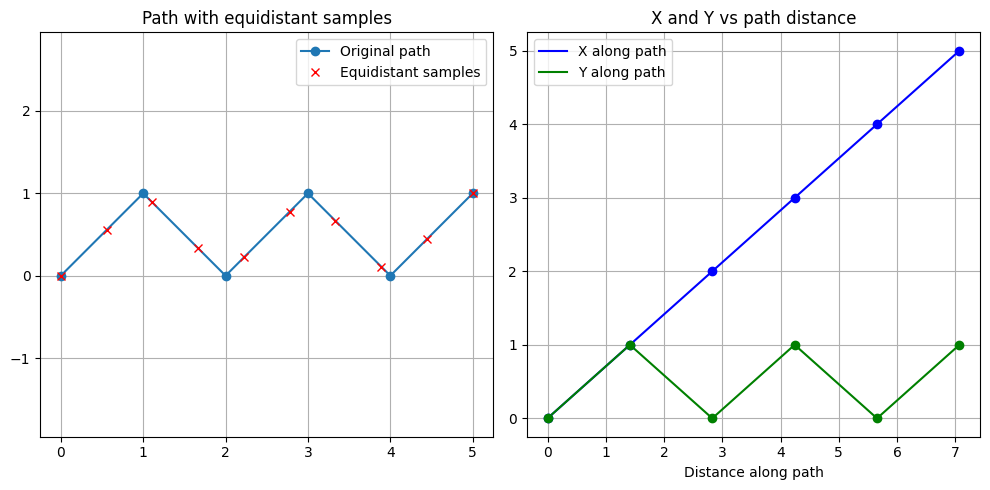


Circle with 12 equidistant samples:
X: [ 1.     0.84   0.415 -0.142 -0.654 -0.958 -0.958 -0.654 -0.142  0.415
  0.84   1.   ]
Y: [ 0.     0.54   0.909  0.988  0.755  0.281 -0.281 -0.755 -0.988 -0.909
 -0.54  -0.   ]


In [53]:
def sample_equidistant(X, Y, n_samples):
    """Sample a path at equidistant intervals."""
    # Compute cumulative distance along path
    dx = np.diff(X)
    dy = np.diff(Y)
    distances = np.sqrt(dx**2 + dy**2)
    cumulative_dist = np.concatenate([[0], np.cumsum(distances)])
    total_dist = cumulative_dist[-1]
    
    # Desired distances for sampling
    sample_dists = np.linspace(0, total_dist, n_samples)
    
    # Interpolate at sample points
    X_sample = np.interp(sample_dists, cumulative_dist, X)
    Y_sample = np.interp(sample_dists, cumulative_dist, Y)
    
    return X_sample, Y_sample, cumulative_dist

# Create a path
X = np.array([0, 1, 2, 3, 4, 5])
Y = np.array([0, 1, 0, 1, 0, 1])

print("Path points:")
print("X:", X)
print("Y:", Y)

X_sample, Y_sample, cum_dist = sample_equidistant(X, Y, 10)
print(f"\n{len(X_sample)} equidistant samples:")
print("X:", X_sample.round(3))
print("Y:", Y_sample.round(3))

# Plot the path (if matplotlib is available)
try:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 5))
    
    # Original path
    plt.subplot(1, 2, 1)
    plt.plot(X, Y, 'o-', label='Original path')
    plt.plot(X_sample, Y_sample, 'rx', label='Equidistant samples')
    plt.legend()
    plt.grid(True)
    plt.title('Path with equidistant samples')
    plt.axis('equal')
    
    # Distance along path
    plt.subplot(1, 2, 2)
    plt.plot(cum_dist, X, 'b-', label='X along path')
    plt.plot(cum_dist, Y, 'g-', label='Y along path')
    plt.plot(cum_dist, X, 'bo')
    plt.plot(cum_dist, Y, 'go')
    plt.xlabel('Distance along path')
    plt.grid(True)
    plt.title('X and Y vs path distance')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

# Create a circular path
theta = np.linspace(0, 2*np.pi, 50)
X_circle = np.cos(theta)
Y_circle = np.sin(theta)

X_sample_circle, Y_sample_circle, _ = sample_equidistant(X_circle, Y_circle, 12)
print(f"\nCircle with {len(X_sample_circle)} equidistant samples:")
print("X:", X_sample_circle.round(3))
print("Y:", Y_sample_circle.round(3))

#### 99. Given an integer n and a 2D array X, select from X the rows which can be interpreted as draws from a multinomial distribution with n degrees, i.e., the rows which only contain integers and which sum to n. (★★★)

In [54]:
def multinomial_rows(X, n):
    """
    Select rows from X that can be draws from a multinomial distribution.
    Rows must contain non-negative integers summing to n.
    """
    # Check if all elements are non-negative integers
    is_int = np.all(np.equal(np.mod(X, 1), 0), axis=1)
    is_non_negative = np.all(X >= 0, axis=1)
    
    # Check if row sums to n
    sums_to_n = np.sum(X, axis=1) == n
    
    # Combine conditions
    valid_rows = is_int & is_non_negative & sums_to_n
    
    return X[valid_rows], valid_rows

# Example
X = np.array([
    [1, 2, 1],   # sums to 4, valid for n=4
    [2, 0, 2],   # sums to 4, valid for n=4
    [0, 3, 0],   # sums to 3, not valid for n=4
    [1, 1, -1],  # negative, not valid
    [1.5, 1, 1.5], # not integers, not valid
    [1, 2, 2],   # sums to 5, not valid for n=4
    [2, 1, 1],   # sums to 4, valid for n=4
    [4, 0, 0],   # sums to 4, valid for n=4
])

n = 4
print(f"X (n={n}):")
print(X)

selected, mask = multinomial_rows(X, n)
print(f"\nRows that are draws from multinomial distribution with n={n}:")
print(selected)

# For different n
for n_test in [3, 4, 5]:
    selected, _ = multinomial_rows(X, n_test)
    print(f"\nFor n={n_test}: {len(selected)} valid rows")

# Generate random multinomial draws
def generate_multinomial_rows(n, num_rows, num_categories):
    """Generate random rows from multinomial distribution."""
    # Generate probabilities
    probs = np.random.dirichlet(np.ones(num_categories), size=num_rows)
    # Sample from multinomial
    rows = np.zeros((num_rows, num_categories), dtype=int)
    for i, p in enumerate(probs):
        rows[i] = np.random.multinomial(n, p)
    return rows

multinomial_data = generate_multinomial_rows(10, 5, 3)
print("\nGenerated multinomial data:")
print(multinomial_data)
print(f"Sums: {np.sum(multinomial_data, axis=1)}")

X (n=4):
[[ 1.   2.   1. ]
 [ 2.   0.   2. ]
 [ 0.   3.   0. ]
 [ 1.   1.  -1. ]
 [ 1.5  1.   1.5]
 [ 1.   2.   2. ]
 [ 2.   1.   1. ]
 [ 4.   0.   0. ]]

Rows that are draws from multinomial distribution with n=4:
[[1. 2. 1.]
 [2. 0. 2.]
 [2. 1. 1.]
 [4. 0. 0.]]

For n=3: 1 valid rows

For n=4: 4 valid rows

For n=5: 1 valid rows

Generated multinomial data:
[[2 2 6]
 [0 4 6]
 [0 7 3]
 [0 5 5]
 [9 1 0]]
Sums: [10 10 10 10 10]


#### 100. Compute bootstrapped 95% confidence intervals for the mean of a 1D array X (i.e., resample the elements of an array with replacement N times, compute the mean of each sample, and then compute percentiles over the means). (★★★)

Data statistics:
Mean: 9.792
Std: 1.807
Size: 100

95% Confidence interval for mean: [9.455, 10.126]
Mean of bootstrap means: 9.795
Std of bootstrap means: 0.176

Vectorized 95% CI: [9.423, 10.138]
Methods match: False


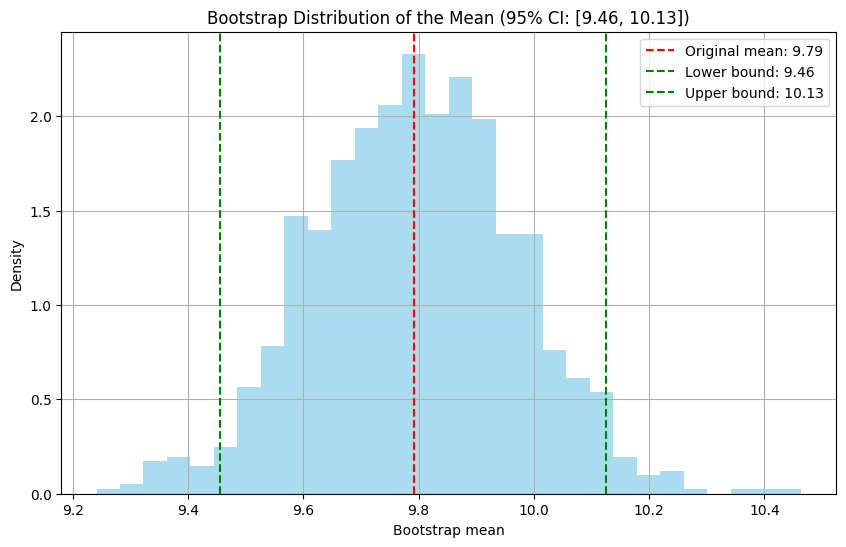

In [55]:
def bootstrap_ci(X, n_bootstrap=1000, confidence=0.95):
    """
    Compute bootstrapped confidence intervals for the mean.
    """
    # Number of samples
    n = len(X)
    
    # Generate bootstrap samples
    bootstrap_means = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        # Sample with replacement
        bootstrap_sample = np.random.choice(X, size=n, replace=True)
        bootstrap_means[i] = np.mean(bootstrap_sample)
    
    # Calculate percentiles
    lower_percentile = (1 - confidence) / 2 * 100
    upper_percentile = (1 + confidence) / 2 * 100
    
    lower_bound = np.percentile(bootstrap_means, lower_percentile)
    upper_bound = np.percentile(bootstrap_means, upper_percentile)
    
    return lower_bound, upper_bound, bootstrap_means

def bootstrap_ci_vectorized(X, n_bootstrap=1000, confidence=0.95):
    """Vectorized version of bootstrap confidence intervals."""
    n = len(X)
    
    # Generate all bootstrap samples at once
    indices = np.random.randint(0, n, size=(n_bootstrap, n))
    bootstrap_samples = X[indices]
    
    # Compute means
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    
    # Calculate percentiles
    alpha = (1 - confidence) / 2
    lower_bound = np.percentile(bootstrap_means, alpha * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha) * 100)
    
    return lower_bound, upper_bound, bootstrap_means

# Example
np.random.seed(42)
X = np.random.normal(loc=10, scale=2, size=100)
print("Data statistics:")
print(f"Mean: {np.mean(X):.3f}")
print(f"Std: {np.std(X):.3f}")
print(f"Size: {len(X)}")

# Bootstrap confidence intervals
lower, upper, means = bootstrap_ci(X, n_bootstrap=1000)
print(f"\n95% Confidence interval for mean: [{lower:.3f}, {upper:.3f}]")
print(f"Mean of bootstrap means: {np.mean(means):.3f}")
print(f"Std of bootstrap means: {np.std(means):.3f}")

# Vectorized version
lower_v, upper_v, means_v = bootstrap_ci_vectorized(X, n_bootstrap=1000)
print(f"\nVectorized 95% CI: [{lower_v:.3f}, {upper_v:.3f}]")
print("Methods match:", np.allclose([lower, upper], [lower_v, upper_v]))

# Plot histogram of bootstrap means (if matplotlib available)
try:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 6))
    plt.hist(means, bins=30, density=True, alpha=0.7, color='skyblue')
    plt.axvline(np.mean(X), color='red', linestyle='--', label=f'Original mean: {np.mean(X):.2f}')
    plt.axvline(lower, color='green', linestyle='--', label=f'Lower bound: {lower:.2f}')
    plt.axvline(upper, color='green', linestyle='--', label=f'Upper bound: {upper:.2f}')
    plt.xlabel('Bootstrap mean')
    plt.ylabel('Density')
    plt.title(f'Bootstrap Distribution of the Mean (95% CI: [{lower:.2f}, {upper:.2f}])')
    plt.legend()
    plt.grid(True)
    plt.show()
except ImportError:
    pass